# Deformation in and around Askja volcano, Iceland

<div style="text-align: justify">

In this example notebook we create, from scratch, a basic model for the deformation field at Askja volcano, Iceland. From this model we compute and visualise the displacement, strain, and stress fields in and around the volcano.

<hr>

This example is based on modelling originally performed for:

> `Bacon, C.A., Johnson, J.H., White, R.S. and Rawlinson, N., 2022. On the origin of seismic anisotropy in the shallow crust of the Northern Volcanic Zone, Iceland. Journal of Geophysical Research: Solid Earth, 127(1), p.e2021JB022655.`
> 
<hr>

This example is a Jupyter "notebook"—a browser-based platform that allows developers to code, visualise, and add additional explanatory text inside a single document. Treat it as a Python script that you can edit and re-run sections of on the fly.

As is standard with any Python script, we import all of the modules required to run everything at the top.
</div>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pyproj import Transformer
import pandas as pd
from pathlib import Path
import glob
import numpy as np
from scipy.interpolate import griddata
from pathlib import Path


import okada.plot
from okada import evaluate, read_model, Model
from okada.elements.point_source import PointInflation
from okada.elements.tensile_crack import TensileCrack

## Building the deformation model

<div style="text-align: justify">

There a number of different mechanisms contributing to the overall deformation field in and around Askja. As we are treating the problem as a linear elastic one, we can compute the contributions from each constituent part of the model and stack them linearly to find the final deformation field.

There are two primary contributions to deformation in the Northern Volcanic Zone around Askja:

1. the deformation associated with extension (plate-spreading) along the divergent margin. Previous work has treated this extension as a buried dislocation—that is, opening on a tensile crack that extends from some locking depth to infinite. Above the locking depth, the opening of the tensile crack diminishes to zero (or, in order to avoid singularities, the _gradient_ of the opening tends to zero at some depth). This depth is derived from the observed brittle-ductile transition in the crust, as determined from earthquake hypocentres across the Northern Volcanic Zone;
2. and deflation centred underneath Askja caldera modelled as a infinitesimal point source (a "Mogi"-like source), the potency of which has been constrained by geodetic observations across Askja made since the 1980s.

The contributions from plate-spreading are distributed across the rift segments that accompany the central volcanoes along the Northern Volcanic Zone. The tensile-opening potency is taken to be equal to the far-field plate-spreading speed.

We start by defining a number of basic elastic parameters, the values of which are approximations that are appropriate for this region:
</div>

In [37]:
poisson_ratio = 0.25
youngs_modulus = 450_000
friction_coefficient = 0.4  # Not actually used

<div style="text-align: justify">

Next, we define the coordinates in space on which we wish to compute our analytical solutions to the model. Here we use a simple, regular Cartesian grid (90 km by 120 km, with a node spacing of 1 km), but it is entirely possible to use any x/y coordinate sets.

We tie this Cartesian grid to our geographic coordinate space with a projection transformation, using the `PYPROJ` package, and a reference point which in this instance is equivalent to the (0, 0) origin of the Cartesian grid.
</div>

In [38]:
x_inc = 1.0
x_coords = np.arange(0.0, 90.0 + x_inc, x_inc)
x_coords = np.ascontiguousarray(x_coords, dtype=np.float64)

y_inc = 1.0
y_coords = np.arange(0.0, 120.0 + y_inc, y_inc)
y_coords = np.ascontiguousarray(y_coords, dtype=np.float64)

x_coords, y_coords = np.meshgrid(x_coords, y_coords, indexing="ij")

transformer = Transformer.from_crs(
    crs_from="EPSG:4326", crs_to="EPSG:32628", always_xy=True
)
reference_coords = (-17.6, 64.5)
REF_X, REF_Y = transformer.transform(*reference_coords)

In [39]:
transformer2 = Transformer.from_crs(
    crs_to="EPSG:4326", crs_from="EPSG:32628", always_xy=True
)

<div style="text-align: justify">

Now we can proceed with building our model by defining its constituent elements, starting with the deflation source.

The parameters for our point source of deflation are taken from direct inversions of geodetic data (both GNSS and InSAR data) recorded across the Northern Volcanic Zone. These best-fitting models are presented in:

> `Drouin, V., Sigmundsson, F., Ófeigsson, B.G., Hreinsdóttir, S., Sturkell, E. and Einarsson, P., 2017. Deformation in the Northern Volcanic Zone of Iceland 2008–2014: An interplay of tectonic, magmatic, and glacial isostatic deformation. Journal of Geophysical Research: Solid Earth, 122(4), pp.3158-3178.`

From Table 4 in this paper, we get the following Mogi parameters for Askja:

* Depth: 3.5 km
* Latitude: 65.050
* Longitude: −16.778
* dV: -0.99 m^3 / yr

We can use our coordinate transformer, along with our reference point (the (0.0, 0.0) coordinate origin of the grid, in this case) to put this into our Cartesian space.
</div>

In [40]:
mogi_coords = (-16.778, 65.050, 3.5)
mogi_x, mogi_y, mogi_z = transformer.transform(*mogi_coords)
mogi_x = round((mogi_x - REF_X) / 1000, ndigits=3)
mogi_y = round((mogi_y - REF_Y) / 1000, ndigits=3)

In [41]:
deflation_source = PointInflation(
    x_start=mogi_x,
    x_end=mogi_x + 0.001,
    y_start=mogi_y,
    y_end=mogi_y + 0.001,
    z_start=mogi_z + 0.001,
    z_end=mogi_z,
    dip_angle=90.0,
    tensile_opening=0.0,
    point_opening=-0.99e6,  # This is the opening potency, with units of m^3
)

<div style="text-align: justify">

The rift segments are built as a composite of tensile-opening cracks, where the amount of opening is a monotonic function with depth between 5.75 km (the 'locking depth', above which the crust is in an entirely brittle regime) and 7 km (below which the crust is in an entirely ductile regime). Below 7 km, opening equals the full plate-spreading rate (in this case 18 mm / year).

We use here a cubic polynomial as our monotonic function, tuned so as to guarantee a zero gradient at both ends of the depth range.
</div>

In [42]:
def opening_distribution(
    z: float, z_lock: float, z_bd: float, spreading_rate: float, method: str = "cubic"
) -> float:
    """
    Calculate plate-spreading as a function of depth.

    Parameters
    ----------
    z: Depth (positive downward).
    z_lock: Locking depth.
    z_bd: Brittle-ductile transition depth.
    spreading_rate: Full plate-spreading rate.
    method: Specify the function to be used to compute the opening.

    Returns
    -------
    opening: Plate opening at depth z.

    """

    if z <= z_lock:  # Above locking depth
        opening = 0
    elif z >= z_bd:  # Below brittle-ductile transition
        opening = spreading_rate
    else:  # Transition zone
        # Normalize depth to [0,1] interval
        zn = (z - z_lock) / (z_bd - z_lock)

        if method == "cubic":
            # Cubic polynomial satisfying boundary conditions
            # f(0) = 0, f'(0) = 0, f(1) = spreading_rate, f'(1) = 0
            opening = spreading_rate * (3 * zn**2 - 2 * zn**3)
        elif method == "quintic":
            # Quintic polynomial
            # f(0) = 0, f'(0) = 0, f''(0) = 0
            # f(1) = spreading_rate, f'(1) = 0, f''(1) = 0
            opening = spreading_rate * (10 * zn**3 - 15 * zn**4 + 6 * zn**5)
        elif method == "linear":
            # Linear transition
            # f(0) = 0, f(1) = spreading_rate
            opening = spreading_rate * zn
        else:
            raise ValueError("Method must be either 'linear' or 'cubic' (default).")

    return opening

<div style="text-align: justify">

We can (optionally) quickly visualise what three different opening distributions look like: 'linear', 'cubic', and 'quintic':
</div>

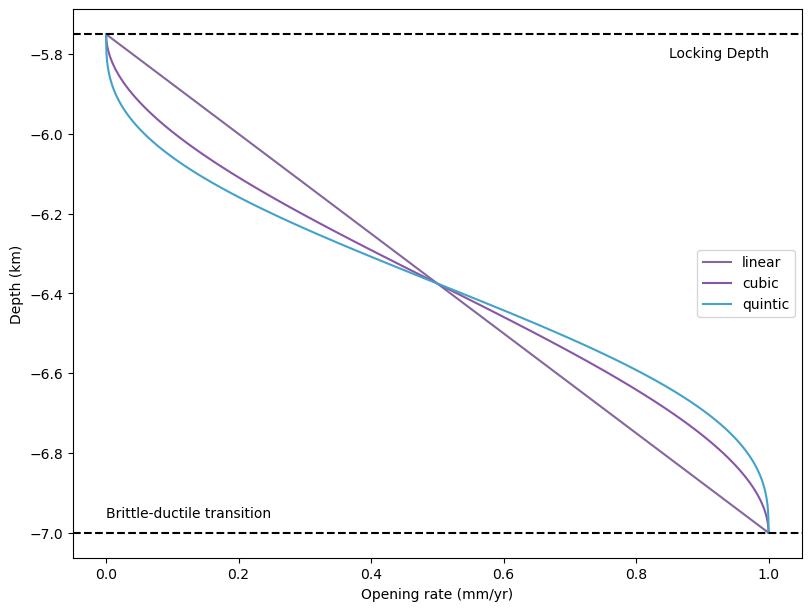

In [43]:
locking_depth = 5.75  # km
brittle_ductile_depth = 7.0  # km
sample_points = 126  # Number of points to sample across the boundary
z = np.linspace(locking_depth, brittle_ductile_depth, sample_points)
z_increment = z[1] - z[0]

fig, ax = plt.subplots(1, figsize=(8, 6), constrained_layout=True)

for method, c in zip(["linear", "cubic", "quintic"], ["#84679F", "#8856a7", "#43a2ca"]):
    opening = [
        opening_distribution(
            zi, locking_depth, brittle_ductile_depth, 1.0, method=method
        )
        for zi in z
    ]

    ax.plot(opening, -z, c=c, label=method)

ax.axhline(-locking_depth, color="k", linestyle="--")
ax.text(1.0, -5.78, "Locking Depth", ha="right", va="top")
ax.axhline(-brittle_ductile_depth, color="k", linestyle="--")
ax.text(0.0, -6.97, "Brittle-ductile transition", ha="left", va="bottom")
ax.set_xlabel("Opening rate (mm/yr)")
ax.set_ylabel("Depth (km)")
_ = plt.legend()

Now, we loop over each rift segment (each corresponding to a central volcano) and build our buried dislocation model:

In [44]:
rift_segments = [
    [(-17.000, 64.810), (-16.400, 65.400), 0.018],  # Askja
    [(-16.650, 64.650), (-16.050, 65.050), 0.002],  # Krafla - assuming less active
    [(-17.464, 64.600), (-17.070, 64.930), 0.018],  # Bardarbunga
    [(-16.750, 65.300), (-16.600, 65.500), 0.018],  # Namafjall
]

rift_elements = []
for rift_segment in rift_segments:
    start_coord, end_coord, spreading_rate = rift_segment
    x_start, y_start = transformer.transform(*start_coord)
    x_end, y_end = transformer.transform(*end_coord)

    x_start, x_end = [round((x - REF_X) / 1000, ndigits=3) for x in [x_start, x_end]]
    y_start, y_end = [round((y - REF_Y) / 1000, ndigits=3) for y in [y_start, y_end]]
    opening = [
        opening_distribution(
            zi, locking_depth, brittle_ductile_depth, spreading_rate, method="cubic"
        )
        for zi in z
    ]
    for o, zi in zip(opening, z):
        if zi == brittle_ductile_depth:
            # Final element spanning from brittle-ductil depth to 'infinity'
            z_lower = 100.0
        else:
            z_lower = round(zi + z_increment, ndigits=3)
        element = TensileCrack(
            x_start,
            x_end,
            y_start,
            y_end,
            round(zi, ndigits=3),
            z_lower,
            90.0,
            tensile_slip=round(o, ndigits=5),
        )
        rift_elements.append(element)

We now combine everything into a `Model` object, which we use as an input for `OkadaPy` computations.

In [45]:
elements = [deflation_source, *rift_elements]

model = Model(
    poisson_ratio,
    youngs_modulus,
    friction_coefficient,
    elements,
    x_coords.flatten(),
    y_coords.flatten(),
    transformer=transformer,
)


We can then set up export functions for the results we are interested in, which are maximum horizontal stress, volumetric strain and horizontal differential stress

In [ ]:
def stress_results_export(mod, stress_res, transformer, depth=None, results_dir=None):
    # Get grid coordinates and stress vectors
        X, Y = mod.grid_xy
        vectors = list(stress_res.shmax_vectors())
        max_directions = [v[0] for v in vectors]
        
        # Create dataframe with vectors and grid coords
        df = pd.DataFrame({
            'X': X.flatten(),
            'Y': Y.flatten(),
            'X_vec': [d[0] for d in max_directions], 
            'Y_vec': [d[1] for d in max_directions]
        })
        
        # Filter for 2km increments starting at 1km
        df = df[((df['X'] - 1) % 2 == 0) & ((df['Y'] - 1) % 2 == 0)]
        # Convert grid coordinates back to lat/lon  
        lons, lats = [], []
        for x, y in zip(df['X'], df['Y']):
            lon, lat = transformer.transform(x*1000 + REF_X, y*1000 + REF_Y, direction='INVERSE')
            lons.append(lon)
            lats.append(lat)
            
        df['longitude'] = lons
        df['latitude'] = lats
        
        # Calculate direction angle in degrees
        df['direction'] = np.degrees(np.arctan2(df['Y_vec'], df['X_vec']))
        
        # Export to CSV
        output_dir = Path(results_dir) if results_dir is not None else Path(".")
        output_dir.mkdir(parents=True, exist_ok=True)
        filename = 'stress_vectors.csv' if depth is None else f"stress_vectors_depth_{depth}km.csv"
        df[['longitude', 'latitude', 'direction']].to_csv(output_dir / filename, index=False)
        
        return df

def strain_results_export(mod, strain_res, transformer, depth=None, results_dir=None):
    # Get grid coordinates and strain values
    X, Y = mod.grid_xy
    # Compute volumetric strain: sum of diagonal components (assuming last axis: [exx, eyy, ezz, ...])
    # Result will be flattened to align with grid
    volumetric_strain = (strain_res.strain[..., 0] + strain_res.strain[..., 1] + strain_res.strain[..., 2]).flatten()
    
    df = pd.DataFrame({
        'X': X.flatten(),
        'Y': Y.flatten(),
        'volumetric_strain': volumetric_strain
    })
    
    # Filter for 0.1 km increments starting at 0.1 km
    step_km = 0.1
    offset_km = 0.1
    df = df[
        np.isclose((df['X'] - offset_km) % step_km, 0, atol=1e-8)
        & np.isclose((df['Y'] - offset_km) % step_km, 0, atol=1e-8)
    ]
    # Convert grid coordinates back to lat/lon  
    lons, lats = [], []
    for x, y in zip(df['X'], df['Y']):
        lon, lat = transformer.transform(x*1000 + REF_X, y*1000 + REF_Y, direction='INVERSE')
        lons.append(lon)
        lats.append(lat)
    
    df['longitude'] = lons
    df['latitude'] = lats
    
    # Export to CSV
    output_dir = Path(results_dir) if results_dir is not None else Path(".")
    output_dir.mkdir(parents=True, exist_ok=True)
    filename = 'volumetric_strain_values.csv' if depth is None else f"volumetric_strain_values_depth_{depth}km.csv"
    df[['longitude', 'latitude', 'volumetric_strain']].to_csv(output_dir / filename, index=False)
    
    return df


def horizontal_deviatoric_stress_export(mod, stress_res, transformer, depth=None, results_dir=None):
    # Get grid coordinates and horizontal stress components
    X, Y = mod.grid_xy
    sxx = stress_res.stress[..., 0]
    syy = stress_res.stress[..., 1]
    sxy = stress_res.stress[..., 5]

    # Remove 2-D mean stress to get deviatoric components
    mean_stress = 0.5 * (sxx + syy)
    sxx_dev = sxx - mean_stress
    syy_dev = syy - mean_stress
    sxy_dev = sxy

    # 2-D deviatoric stress invariant (always positive)
    horizontal_dev = np.sqrt(sxx_dev**2 + syy_dev**2 + 2 * sxy_dev**2)

    df = pd.DataFrame({
        'X': X.flatten(),
        'Y': Y.flatten(),
        'horizontal_deviatoric_stress': horizontal_dev.flatten()
    })

    # Filter for 0.1 km increments starting at 0.1 km
    step_km = 0.1
    offset_km = 0.1
    df = df[
        np.isclose((df['X'] - offset_km) % step_km, 0, atol=1e-8)
        & np.isclose((df['Y'] - offset_km) % step_km, 0, atol=1e-8)
    ]
    # Convert grid coordinates back to lat/lon
    lons, lats = [], []
    for x, y in zip(df['X'], df['Y']):
        lon, lat = transformer.transform(x*1000 + REF_X, y*1000 + REF_Y, direction='INVERSE')
        lons.append(lon)
        lats.append(lat)

    df['longitude'] = lons
    df['latitude'] = lats

    # Export to CSV
    output_dir = Path(results_dir) if results_dir is not None else Path(".")
    output_dir.mkdir(parents=True, exist_ok=True)
    filename = (
        'horizontal_deviatoric_stress_values.csv'
        if depth is None
        else f"horizontal_deviatoric_stress_values_depth_{depth}km.csv"
    )
    df[['longitude', 'latitude', 'horizontal_deviatoric_stress']].to_csv(
        output_dir / filename, index=False
    )

    return df


def horizontal_principal_stress_diff_export(
    mod, stress_res, transformer, depth=None, results_dir=None
):
    # Get grid coordinates and horizontal stress components
    X, Y = mod.grid_xy
    sxx = stress_res.stress[..., 0]
    syy = stress_res.stress[..., 1]
    sxy = stress_res.stress[..., 5]

    # Principal stress differential in horizontal plane (sigma1 - sigma2)
    horizontal_principal_diff = np.sqrt((sxx - syy) ** 2 + 4 * sxy**2)

    df = pd.DataFrame({
        'X': X.flatten(),
        'Y': Y.flatten(),
        'horizontal_principal_stress_diff': horizontal_principal_diff.flatten()
    })

    # Filter for 0.1 km increments starting at 0.1 km
    step_km = 0.1
    offset_km = 0.1
    df = df[
        np.isclose((df['X'] - offset_km) % step_km, 0, atol=1e-8)
        & np.isclose((df['Y'] - offset_km) % step_km, 0, atol=1e-8)
    ]
    # Convert grid coordinates back to lat/lon
    lons, lats = [], []
    for x, y in zip(df['X'], df['Y']):
        lon, lat = transformer.transform(x*1000 + REF_X, y*1000 + REF_Y, direction='INVERSE')
        lons.append(lon)
        lats.append(lat)

    df['longitude'] = lons
    df['latitude'] = lats

    # Export to CSV
    output_dir = Path(results_dir) if results_dir is not None else Path(".")
    output_dir.mkdir(parents=True, exist_ok=True)
    filename = (
        'horizontal_principal_stress_diff_values.csv'
        if depth is None
        else f"horizontal_principal_stress_diff_values_depth_{depth}km.csv"
    )
    df[['longitude', 'latitude', 'horizontal_principal_stress_diff']].to_csv(
        output_dir / filename, index=False
    )

    return df




We can then compute the results for a range of depths and export them

In [ ]:
depth_range = np.arange(0,6,1)



# Evaluate displacement, strain, and stress at 0.0 km depth
# depth = 0.0
n_threads = 16
results_dir = Path("../model_results")
results_dir.mkdir(parents=True, exist_ok=True)

for depth in depth_range:
    # displacement_result = evaluate(model, depth, "displacement", threads=n_threads)
    strain_result = evaluate(model, depth, "strain", threads=n_threads)
    stress_result = evaluate(model, depth, "stress", threads=n_threads)
    
    strain_results_export(model, strain_result, transformer, depth=depth, results_dir=results_dir)
    stress_results_export(model, stress_result, transformer, depth=depth, results_dir=results_dir)
    horizontal_deviatoric_stress_export(model, stress_result, transformer, depth=depth, results_dir=results_dir)
    horizontal_principal_stress_diff_export(
        model, stress_result, transformer, depth=depth, results_dir=results_dir
    )
    
    
    
    
    
    



	Computing strain solution...
		Elapsed time: 0.928501 seconds.
	...complete.
	Computing stress solution...
		Elapsed time: 0.880684 seconds.
	...complete.
	Computing strain solution...
		Elapsed time: 0.951512 seconds.
	...complete.
	Computing stress solution...
		Elapsed time: 0.919320 seconds.
	...complete.
	Computing strain solution...
		Elapsed time: 0.885913 seconds.
	...complete.
	Computing stress solution...
		Elapsed time: 0.993520 seconds.
	...complete.
	Computing strain solution...
		Elapsed time: 0.899625 seconds.
	...complete.
	Computing stress solution...
		Elapsed time: 0.895106 seconds.
	...complete.
	Computing strain solution...
		Elapsed time: 0.926660 seconds.
	...complete.
	Computing stress solution...
		Elapsed time: 0.880606 seconds.
	...complete.


We then can interpolate between our strain, and differential stress grids for plotting clarity~

In [ ]:

def interpolate_csv_to_xyz(
    csv_file,
    output_xyz=None,
    spacing=0.002,  # much finer grid spacing (~220 m)
    method="linear",
    region=None,
    value_column=None,
):
    """
    Read one CSV with columns longitude, latitude, value_column and
    interpolate onto a regular lon/lat grid, writing an XYZ file for GMT.

    Parameters
    ----------
    csv_file : str | Path
        Path to CSV file with columns: longitude, latitude, value_column.
    output_xyz : str | Path | None
        Output XYZ file path. If None, writes next to the CSV with
        "_interpolated.xyz" appended to the stem.
    spacing : float
        Grid spacing in degrees (e.g., 0.002 ~= 220 m).
    method : str
        Interpolation method: "linear", "nearest", or "cubic".
    region : tuple | None
        (min_lon, max_lon, min_lat, max_lat). If None, uses data bounds.
    value_column : str | None
        Column name for the value to interpolate. If None, uses the first
        non-longitude/latitude column.
    """
    data = pd.read_csv(csv_file)

    if value_column is None:
        candidates = [c for c in data.columns if c not in ("longitude", "latitude")]
        if not candidates:
            raise ValueError("No value column found (expected a third column).")
        value_column = candidates[0]

    lon = data["longitude"].to_numpy()
    lat = data["latitude"].to_numpy()
    val = data[value_column].to_numpy()

    if region is None:
        min_lon, max_lon = lon.min(), lon.max()
        min_lat, max_lat = lat.min(), lat.max()
    else:
        min_lon, max_lon, min_lat, max_lat = region

    grid_lon = np.arange(min_lon, max_lon + spacing, spacing)
    grid_lat = np.arange(min_lat, max_lat + spacing, spacing)
    grid_lon_mesh, grid_lat_mesh = np.meshgrid(grid_lon, grid_lat)

    grid_val = griddata(
        (lon, lat),
        val,
        (grid_lon_mesh, grid_lat_mesh),
        method=method,
    )

    # Write XYZ: lon lat value (skip NaNs)
    out = np.column_stack(
        [
            grid_lon_mesh.ravel(),
            grid_lat_mesh.ravel(),
            grid_val.ravel(),
        ]
    )
    out = out[~np.isnan(out[:, 2])]

    csv_path = Path(csv_file)
    if output_xyz is None:
        output_xyz = csv_path.with_name(f"{csv_path.stem}_interpolated.xyz")
    else:
        output_xyz = Path(output_xyz)

    np.savetxt(output_xyz, out, fmt="%.6f %.6f %.10f")
    return output_xyz


def interpolate_csvs_to_xyzs(
    csv_files,
    spacing=0.002,  # use finer grid here also
    method="linear",
    region=None,
    value_column=None,
):
    """
    Interpolate each CSV in a list and write an XYZ per file.

    Returns a list of output XYZ paths.
    """
    outputs = []
    for csv_file in csv_files:
        outputs.append(
            interpolate_csv_to_xyz(
                csv_file,
                output_xyz=None,
                spacing=spacing,
                method=method,
                region=region,
                value_column=value_column,
            )
        )
    return outputs



In [ ]:
# Example usage:
files = glob.glob('../model_results/**deviatoric_stress**.csv')
files.extend(glob.glob('../model_results/**strain**.csv'))
files.extend(glob.glob('../model_results/**horizontal_principal_stress**.csv'))
# Much finer interpolation
outputs = interpolate_csvs_to_xyzs(files, spacing=0.002, method="linear")

In [ ]:
stress_vector_files = glob.glob('../model_results/**stress_vectors**.csv')

In [ ]:
from pathlib import Path

def normalize_azimuth(deg):
    """Normalize degrees to [-180, 180)."""
    return ((deg + 180) % 360) - 180


def add_opposite_azimuth_to_csvs(
    csv_files,
    angle_column="direction",
    output_suffix="_with_opposite",
    overwrite=True,
):
    """Append opposite azimuths (angle + 180) for each row in CSVs."""
    outputs = []
    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        if angle_column not in df.columns:
            raise ValueError(f"Missing '{angle_column}' in {csv_file}")

        df_opposite = df.copy()
        df_opposite[angle_column] = normalize_azimuth(
            df_opposite[angle_column].to_numpy() + 180
        )

        df_out = pd.concat([df, df_opposite], ignore_index=True)

        csv_path = Path(csv_file)
        if overwrite:
            out_path = csv_path
        else:
            out_path = csv_path.with_name(f"{csv_path.stem}{output_suffix}{csv_path.suffix}")

        df_out.to_csv(out_path, index=False)
        outputs.append(out_path)

    return outputs

# Example usage (overwrites in place by default):
outputs = add_opposite_azimuth_to_csvs(stress_vector_files)
# If you want a new file name, set overwrite=False:
# outputs = add_opposite_azimuth_to_csvs(stress_vector_files, overwrite=False)